In [5]:
import numpy as np
np.bool = bool
import matplotlib.pyplot as plt

from wzk import sql2, trajectory
# allow reload of python modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_one-world copy.db'
# TODO change to you own file path
n_voxels = 64
voxel_size = 10 / 64     # in m
extent = [0, 10, 0, 10]  # in m
n_waypoints = 20  # start + 20 inner points + end
n_dim = 2
n_paths_per_world = 10000
n_worlds = 1
worlds = sql2.get_values_sql(file=file, table="worlds", values_only=False)
print(worlds.head())

   world_i32                                            img_cmp
0          0  b'x\xda\xcd\x97I\x16\xc20\x0cC\xad\xfb_\x9a\x0...
1          1  b"x\xda\xed\x97\xcd\x12\xc2 \x0c\x84\xb3\xef\x...
2          2  b'x\xda\xed\x97\xc1\x0e\xc30\x08C\xf1\xff\xff\...
3          3  b"x\xda\xe5\x961\x16\xc30\x08C\xad\xfb_\xbaC\x...
4          4  b'x\xda\xc5\x96A\x12\x850\x08C\xc9\xfd/\xed\xc...


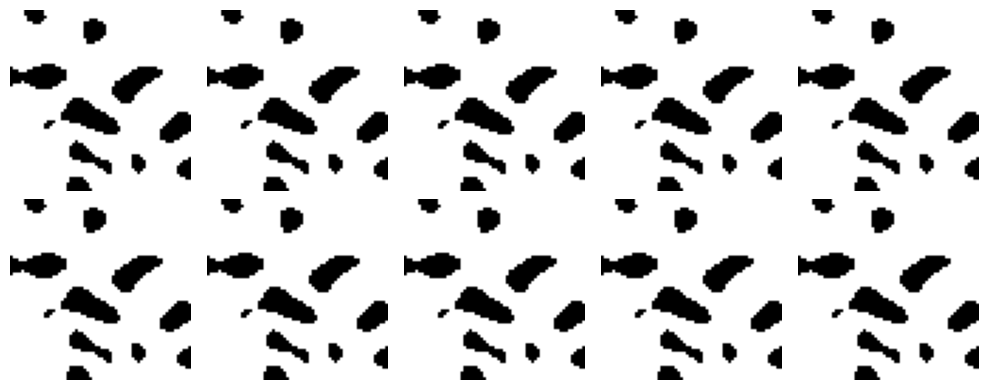

In [8]:
obstacle_images = sql2.compressed2img(img_cmp=worlds.img_cmp.values, shape=(n_voxels, n_voxels), dtype=bool)

# obstacles is (1000, 64, 64) each having 1 world with 64x64 voxels
# show 10 random worlds
n_rows = 2
n_cols = 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(10, 4))

for i in range(n_rows):
    for j in range(n_cols):
        indx = np.random.randint(0, n_worlds)
        axs[i, j].imshow(obstacle_images[indx].T, origin='lower', extent=extent, cmap='binary')
        axs[i, j].axis('off')  # to hide axis

plt.tight_layout()
plt.show()

In [10]:
batch_size = 32
n_total = n_paths_per_world * n_worlds
# batch_idx =     [0, 1, 2, 1000, 2000, 3500]
path_idx_for_batch = np.random.choice(np.arange(n_total), size=batch_size, replace=False)
path_idx_for_whole_dataset = np.arange(10000)

paths = sql2.get_values_sql(file=file, table='paths', rows=path_idx_for_whole_dataset, values_only=False)
print(f'paths columns: {paths.columns}, shape: {paths.shape}')

batch_i_world = paths.world_i32.values
obstacle_images_batch = obstacle_images[batch_i_world]

q_paths = sql2.object2numeric_array(paths.q_f32.values)
q_paths = q_paths.reshape(-1, n_waypoints, n_dim)

paths columns: Index(['world_i32', 'sample_i32', 'q_f32', 'objective_f32', 'feasible_b'], dtype='object'), shape: (10000, 5)


In [11]:
q_paths.shape

(10000, 20, 2)

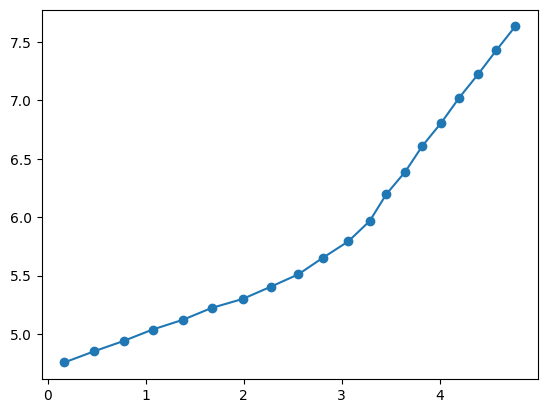

In [12]:
one_path = q_paths[0]
# show this path 
plt.plot(one_path[:, 0], one_path[:, 1], 'o-')

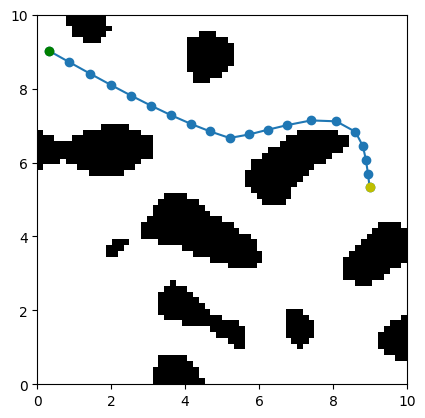

In [13]:
# print 1 path but on world image
indx= 9000
one_path = q_paths[indx]
world_i = batch_i_world[indx]
obstacle_image_i = obstacle_images[world_i]

# show this path
plt.imshow(obstacle_image_i.T, origin='lower', extent=extent, cmap='binary')
plt.plot(one_path[:, 0], one_path[:, 1], 'o-')
# color start green and end yellow 
plt.plot(one_path[0, 0], one_path[0, 1], 'go')
plt.plot(one_path[-1, 0], one_path[-1, 1], 'yo')

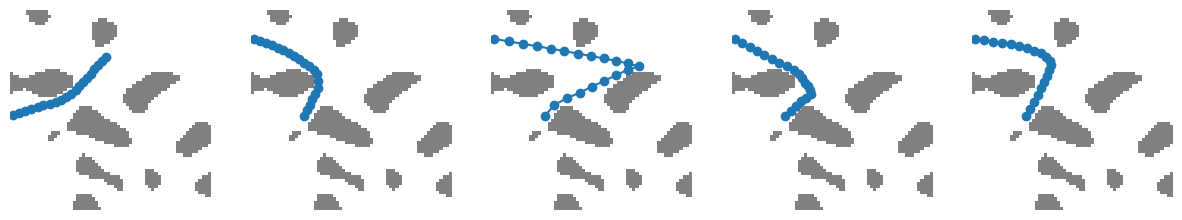

In [14]:
# print a few paths 
n_paths = 5
fig, axs = plt.subplots(1, n_paths, figsize=(15, 3))
for i in range(n_paths):
    axs[i].plot(q_paths[i, :, 0], q_paths[i, :, 1], 'o-')
    axs[i].imshow(obstacle_images_batch[i].T, origin='lower', extent=extent, cmap='binary', alpha=0.5)
    axs[i].axis('off')  # to hide axis

In [15]:
q_paths = sql2.object2numeric_array(paths.q_f32.values)
q_paths = q_paths.reshape(-1, n_waypoints, n_dim)

i0 = 100
i1 = 87

In [16]:
q_paths.shape

(10000, 20, 2)

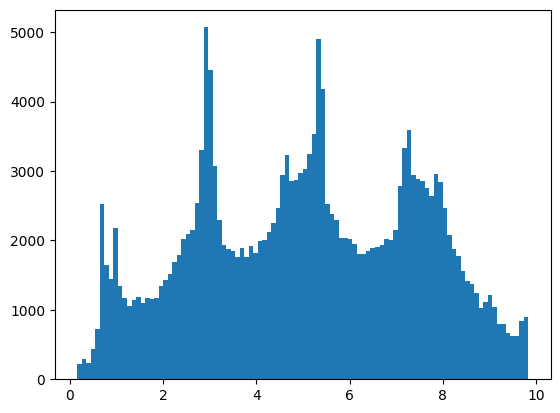

In [17]:
# histogram of q_paths x, y
plt.hist(q_paths[:, :, 1].flatten(), bins=100);

# torch dataset wrapper

In [24]:
from torch_dataset import PathsDataset
dataset = PathsDataset(file=file, n_waypoints=n_waypoints, n_dim=n_dim, n_worlds=n_worlds)

data shape: torch.Size([1000, 20, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0')


In [25]:
dataset.MIN_X_COORDINATE

0

# Normalizer

In [26]:
from normalizer import MinMaxFeatureNormalizer

In [27]:
normalizer = MinMaxFeatureNormalizer(min_values=[dataset.MIN_X_COORDINATE, dataset.MIN_Y_COORDINATE],max_values=[dataset.MAX_X_COORDINATE, dataset.MAX_Y_COORDINATE])

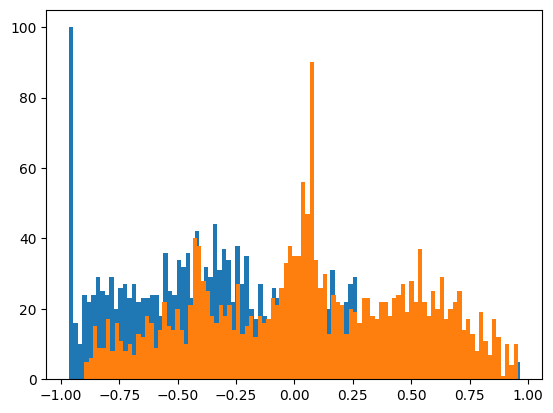

In [29]:
samples = dataset[0:100]
samples = samples.cpu().detach().numpy()
# plot hist of x, y
plt.hist(samples[:, :, 0].flatten(), bins=100);
plt.hist(samples[:, :, 1].flatten(), bins=100);

In [33]:
dataset = PathsDataset(file=file, n_waypoints=n_waypoints, n_dim=n_dim, n_worlds=n_worlds, normalize=False)

data shape: torch.Size([1000, 20, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0')


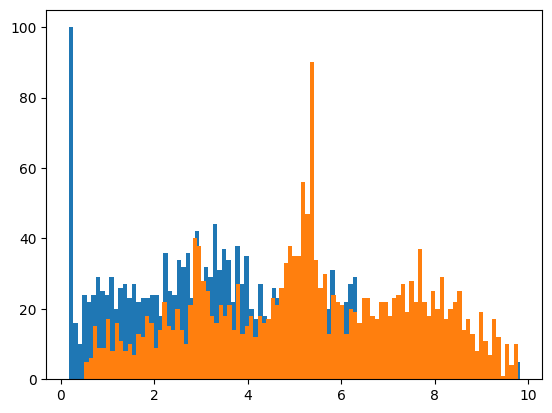

In [34]:
samples = dataset[0:100]
samples = samples.cpu().detach().numpy()
# plot hist of x, y
plt.hist(samples[:, :, 0].flatten(), bins=100);
plt.hist(samples[:, :, 1].flatten(), bins=100);